In [1]:
#
import librosa
import os
import numpy as np

jazz_path = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/jazz'
durations = []

for root, dirs, files in os.walk(jazz_path):
    for file in files:
        if file.endswith('.wav'):
            y, sr = librosa.load(os.path.join(root, file), sr=None)
            durations.append(librosa.get_duration(y=y, sr=sr))

print(f"Mean Duration: {np.mean(durations)}")

Mean Duration: 30.032979591836728


In [2]:
import os
import soundfile as sf

# Define the root path
base_path = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
folders_to_check = ['genres_stems', 'ESC-50-master/audio', 'mashups']

sample_rates = set()

print("Scanning files for sample rates...")

for folder in folders_to_check:
    folder_path = os.path.join(base_path, folder)
    
    if not os.path.exists(folder_path):
        continue
        
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith('.wav'):
                file_path = os.path.join(root, file)
                try:
                    # sf.info reads only the header, making it near-instant
                    info = sf.info(file_path)
                    sample_rates.add(info.samplerate)
                except Exception as e:
                    # This helps you identify if any files are truly corrupted
                    print(f"Error reading {file}: {e}")

# Formatting the output as requested
result = sorted(list(sample_rates))
print(f"\nUnique Sample Rates: {result}")

Scanning files for sample rates...

Unique Sample Rates: [22050, 44100]


In [3]:
import os
import soundfile as sf

train_path = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems'
corrupted_count = 0
zero_byte_count = 0

print("Checking for corrupted or zero-byte files in train dataset...")

for root, _, files in os.walk(train_path):
    for file in files:
        if file.endswith('.wav'):
            file_path = os.path.join(root, file)
            
            # Check 1: Zero-byte files
            if os.path.getsize(file_path) == 0:
                zero_byte_count += 1
                corrupted_count += 1
                continue
            
            # Check 2: Actual corruption (cannot be read)
            try:
                with sf.SoundFile(file_path) as f:
                    pass 
            except Exception:
                corrupted_count += 1

print(f"Total zero-byte files: {zero_byte_count}")
print(f"Total corrupted or zero-byte files: {corrupted_count}")

Checking for corrupted or zero-byte files in train dataset...
Total zero-byte files: 0
Total corrupted or zero-byte files: 0


In [4]:
import os
import librosa
import numpy as np

train_path = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems'
peak_values_db = []

print("Calculating average peak amplitude for vocal stems...")

for root, _, files in os.walk(train_path):
    for file in files:
        if file == 'vocals.wav':
            file_path = os.path.join(root, file)
            
            # Load the audio file
            # sr=None preserves original sample rate; mono=True ensures 1 channel
            y, sr = librosa.load(file_path, sr=None)
            
            # Find the absolute peak amplitude
            peak = np.max(np.abs(y))
            
            # Avoid log of zero for silent files
            if peak > 0:
                peak_db = 20 * np.log10(peak)
                peak_values_db.append(peak_db)

if peak_values_db:
    avg_peak_db = np.mean(peak_values_db)
    print(f"\nAverage Peak Amplitude: {avg_peak_db:.4f} dB")
else:
    print("No vocal stems found.")

Calculating average peak amplitude for vocal stems...

Average Peak Amplitude: -12.4949 dB


In [5]:
import os
import librosa
import numpy as np

# Path to the blues genre folder
blues_path = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues'
all_centroids = []

print("Calculating mean spectral centroid for 'blues'...")

# Loop through every subdirectory (each song) and every stem (.wav)
for root, _, files in os.walk(blues_path):
    for file in files:
        if file.endswith('.wav'):
            file_path = os.path.join(root, file)
            
            # Load audio
            y, sr = librosa.load(file_path, sr=None)
            
            # Calculate spectral centroid for each frame
            # centroid shape is (1, number_of_frames)
            cent = librosa.feature.spectral_centroid(y=y, sr=sr)
            
            # Take the mean of frames for this file, then append to our list
            all_centroids.append(np.mean(cent))

if all_centroids:
    mean_blues_centroid = np.mean(all_centroids)
    print(f"\nMean Spectral Centroid for Blues: {mean_blues_centroid:.4f}")
else:
    print("No audio files found in the blues directory.")

Calculating mean spectral centroid for 'blues'...

Mean Spectral Centroid for Blues: 2296.7827


In [6]:
import os
import librosa
import numpy as np
from tqdm import tqdm

train_root = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems'
genre_results = {}

# Get list of genres (folder names)
genres = [d for d in os.listdir(train_root) if os.path.isdir(os.path.join(train_root, d))]

print("Analyzing spectral centroids across all genres...")

for genre in tqdm(genres):
    genre_path = os.path.join(train_root, genre)
    centroids = []
    
    for root, _, files in os.walk(genre_path):
        for file in files:
            if file.endswith('.wav'):
                file_path = os.path.join(root, file)
                
                # Load and calculate
                y, sr = librosa.load(file_path, sr=None)
                # Compute centroid
                sc = librosa.feature.spectral_centroid(y=y, sr=sr)
                centroids.append(np.mean(sc))
    
    # Store the average for the genre
    genre_results[genre] = np.mean(centroids)

# Find the winner
highest_genre = max(genre_results, key=genre_results.get)

print("\n--- Results ---")
for g, val in sorted(genre_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{g}: {val:.2f}")

print(f"\nGenre with the highest mean spectral centroid: {highest_genre}")

Analyzing spectral centroids across all genres...


100%|██████████| 10/10 [11:42<00:00, 70.24s/it]


--- Results ---
metal: 2579.32
jazz: 2544.11
disco: 2454.15
pop: 2440.88
reggae: 2404.57
hiphop: 2370.79
blues: 2296.78
country: 2266.72
rock: 2250.08
classical: 1674.79

Genre with the highest mean spectral centroid: metal


In [7]:
import os
import librosa
import numpy as np

train_root = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems'
silence_count = 0
# Define silence: amplitude less than 0.0001 (approx -80dB)
SILENCE_THRESHOLD = 1e-4 

print("Scanning for silence in the first 0.5 seconds...")

for root, _, files in os.walk(train_root):
    for file in files:
        if file.endswith('.wav'):
            file_path = os.path.join(root, file)
            
            # duration=0.5 ensures we only load the first half-second
            try:
                y, sr = librosa.load(file_path, sr=None, duration=0.5)
                
                # If the max absolute amplitude is below our threshold, it's "silent"
                if len(y) > 0 and np.max(np.abs(y)) < SILENCE_THRESHOLD:
                    silence_count += 1
            except Exception as e:
                print(f"Error loading {file}: {e}")

print(f"\nTotal stem files containing silence in the first 0.5s: {silence_count}")

Scanning for silence in the first 0.5 seconds...

Total stem files containing silence in the first 0.5s: 333


# Part - 2 

/tmp/ipykernel_55/584409162.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [float(tempo), spec_cent, zcr, rolloff]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_clas

Validation Macro F1 Score: 0.1523

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100



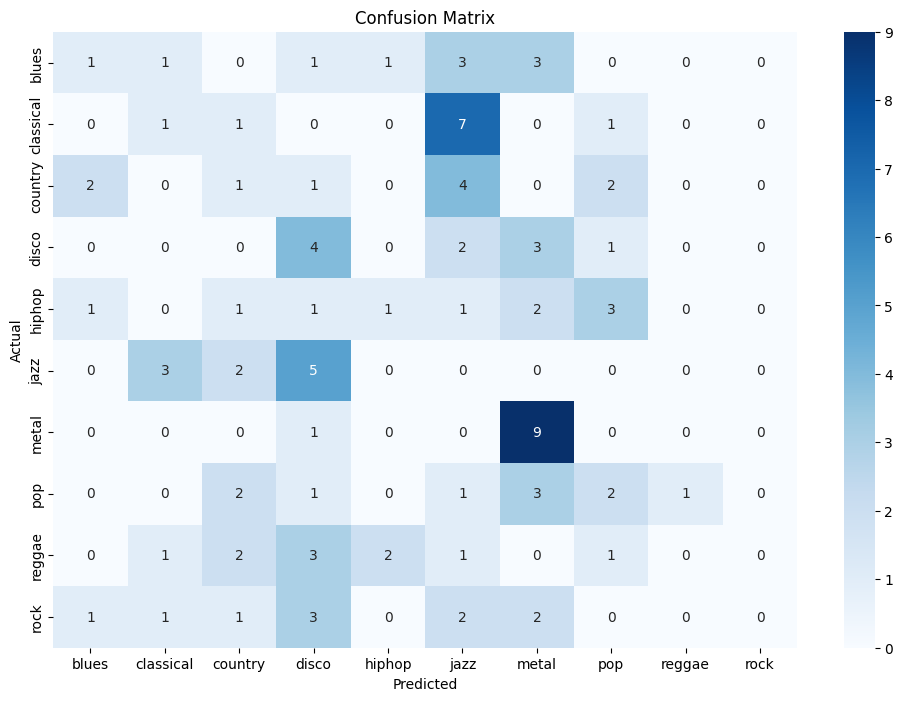


Per-Genre Metrics:
          TP  TN  FP  FN
blues      1  86   4   9
classical  1  84   6   9
country    1  81   9   9
disco      4  74  16   6
hiphop     1  87   3   9
jazz       0  69  21  10
metal      9  77  13   1
pop        2  82   8   8
reggae     0  89   1  10
rock       0  90   0  10


In [8]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)


# --- Completion of Model Training Metrics ---
y_pred = clf.predict(X_val)
macro_f1 = f1_score(y_val, y_pred, average='macro')
cm = confusion_matrix(y_val, y_pred)
cr = classification_report(y_val, y_pred)

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=GENRES, yticklabels=GENRES, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Extracting metrics for each genre
metrics_df = pd.DataFrame(index=GENRES, columns=['TP', 'TN', 'FP', 'FN'])

for i, genre in enumerate(GENRES):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    
    metrics_df.loc[genre] = [TP, TN, FP, FN]

print("\nPer-Genre Metrics:")
print(metrics_df)